In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("../data/processed/orders_clean.csv")
customers = pd.read_csv("../data/processed/customers_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")

print("orders:", orders.shape)
print("customers:", customers.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)

orders: (99441, 12)
customers: (99441, 5)
payments: (103886, 5)
reviews: (99224, 9)


In [3]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

print(orders["order_purchase_timestamp"].dtype)
print(orders["order_purchase_timestamp"].min())
print(orders["order_purchase_timestamp"].max())

datetime64[us]
2016-09-04 21:15:19
2018-10-17 17:30:18


In [4]:
# merge orders with customers
orders_customers = orders.merge(customers[["customer_id", "customer_unique_id"]], 
                                 on="customer_id", 
                                 how="left")

print(orders_customers.shape)
print(orders_customers["customer_unique_id"].nunique(), "unique customers")

(99441, 13)
96096 unique customers


In [5]:
#merge orders_customers with payments
payments_per_order = payments.groupby("order_id")["payment_value"].sum().reset_index()

orders_full = orders_customers.merge(payments_per_order, on="order_id", how="left")

print(orders_full.shape)
print(orders_full["payment_value"].isnull().sum(), "orders with missing payment")

(99441, 14)
1 orders with missing payment


In [6]:
orders_full = orders_full.dropna(subset=["payment_value"])

print(orders_full.shape)

(99440, 14)


For Recency we need a reference point — basically "today" from the dataset's perspective. We use the most recent order date + 1 day.

In [7]:
reference_date = orders_full["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2018-10-18 17:30:18


### Build the RFM table
This is the big one. For each unique customer we calculate:

Recency → how many days since their last order
Frequency → how many orders they made
Monetary → how much they spent in total

In [8]:
rfm = orders_full.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
    frequency=("order_id", "count"),
    monetary=("payment_value", "sum")
).reset_index()

print(rfm.shape)
print(rfm.head())

(96095, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19
2  0000f46a3911fa3c0805444483337064      586          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89


Notice most customers have frequency = 1, which is actually a very common pattern in e-commerce. We'll see this more clearly in the next cell.

In [9]:
print(rfm[["recency", "frequency", "monetary"]].describe())

            recency     frequency      monetary
count  96095.000000  96095.000000  96095.000000
mean     288.730756      1.034809    166.594226
std      153.407846      0.214385    231.428912
min        1.000000      1.000000      0.000000
25%      164.000000      1.000000     63.120000
50%      269.000000      1.000000    108.000000
75%      398.000000      1.000000    183.530000
max      773.000000     17.000000  13664.080000


Recency — average 289 days since last order, max 773 days. Most customers ordered a long time ago, which means we'll likely find a big "at-risk" or "lost" segment.
Frequency — mean of 1.03, 75% of customers ordered exactly once. This is super typical for Brazilian e-commerce. Repeat buyers are rare and therefore very valuable.
Monetary — average €166, but max is €13,664. That's a huge range — meaning we likely have a small group of very high spenders hiding in the data.

One thing to flag: that min = 0.000000 in monetary is suspicious. Let's check it quickly before moving on.

In [10]:
print(rfm[rfm["monetary"] == 0])

                     customer_unique_id  recency  frequency  monetary
29977  4fa4365000c7090fcb8cad5713c6d3db       51          1       0.0
56518  968fac81e2c44fb6c1e3ac2a45e6a102       45          1       0.0


Just 2 customers with zero spending — probably cancelled or fully refunded orders. We'll drop them, they'd confuse the clustering.

In [11]:
rfm = rfm[rfm["monetary"] > 0]

print(rfm.shape)

(96093, 4)


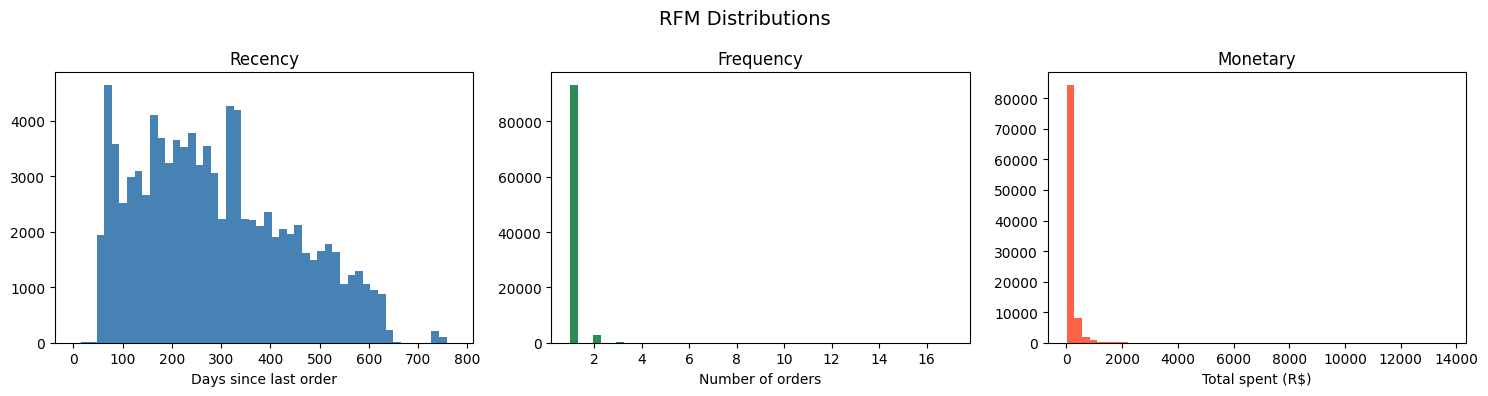

In [12]:
# visualize the rfm distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["recency"], bins=50, color="steelblue")
axes[0].set_title("Recency")
axes[0].set_xlabel("Days since last order")

axes[1].hist(rfm["frequency"], bins=50, color="seagreen")
axes[1].set_title("Frequency")
axes[1].set_xlabel("Number of orders")

axes[2].hist(rfm["monetary"], bins=50, color="tomato")
axes[2].set_title("Monetary")
axes[2].set_xlabel("Total spent (R$)")

plt.suptitle("RFM Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Recency — fairly spread out across 0–700 days. No extreme skew, good.
Frequency — almost everyone ordered exactly once. That giant bar at 1 is 90,000+ customers. Repeat buyers are a tiny minority — which makes them precious.
Monetary — heavily right-skewed. Most customers spent under R$500, but a few spent up to R$13,000. That long tail will mess with clustering if we don't fix it.

This means we need to scale the data before clustering. K-Means uses distances between points — if monetary goes up to 13,000 and frequency only goes to 17, monetary would completely dominate the clustering and frequency would be ignored.
We'll fix this in the next cell with log transformation + standard scaling.

In [13]:
from sklearn.preprocessing import StandardScaler

rfm_log = rfm.copy()
rfm_log["recency"] = np.log1p(rfm["recency"])
rfm_log["frequency"] = np.log1p(rfm["frequency"])
rfm_log["monetary"] = np.log1p(rfm["monetary"])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[["recency", "frequency", "monetary"]])

print("Shape:", rfm_scaled.shape)
print("Mean per feature:", rfm_scaled.mean(axis=0).round(4))
print("Std per feature:", rfm_scaled.std(axis=0).round(4))

Shape: (96093, 3)
Mean per feature: [-0. -0. -0.]
Std per feature: [1. 1. 1.]


log1p → squishes that long tail in monetary and frequency. The R$13,000 outlier no longer dominates
StandardScaler → makes mean=0 and std=1 for all features so no single feature overpowers the others

The Elbow Method
This helps us decide how many clusters (k) to use. We try k=2 to k=10 and look for the "elbow" in the curve.

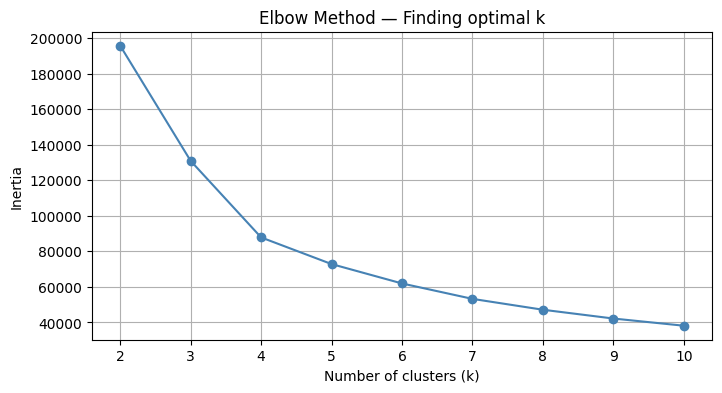

In [14]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", color="steelblue")
plt.title("Elbow Method — Finding optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.savefig("../outputs/figures/rfm_02_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

You mean the Silhouette Score! Great that you remember it — it's a second way to validate the right k, more rigorous than the elbow.
The elbow looks at how tight clusters are (inertia). The silhouette score measures how well each point fits its own cluster compared to other clusters. Score goes from -1 to 1 — closer to 1 is better.

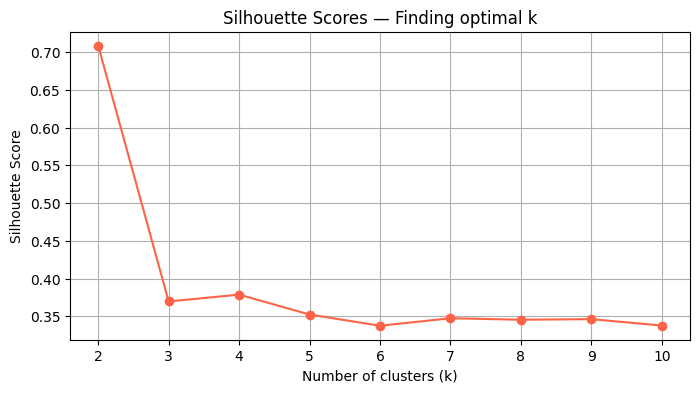

In [15]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker="o", color="tomato")
plt.title("Silhouette Scores — Finding optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True)
plt.savefig("../outputs/figures/rfm_03_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


The elbow is at k=4. You can see the curve drops steeply from 2→3→4, then starts flattening out after 4. Adding more clusters beyond 4 doesn't give you much extra value.
So we'll go with 4 clusters. That gives us enough segments to tell an interesting business story without overcomplicating it.

Interesting! The silhouette score says k=2 is mathematically the best. But here's the thing — k=2 just splits customers into "good" and "bad", which isn't useful for business storytelling.
Look at the curve after k=2 — there's a small bump at k=4, which is the next best option. And it matches our elbow result.

k=2 is statistically cleanest but too simple to be actionable
k=4 gives us enough segments to tell a real business story (loyal, at-risk, bargain hunters, etc.)
Both elbow and silhouette agree k=4 is the sweet spot after k=2

In [16]:
# make clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm["cluster"].value_counts().sort_index())

cluster
0    25277
1    38951
2    28868
3     2997
Name: count, dtype: int64


In [17]:
cluster_profile = rfm.groupby("cluster").agg(
    recency=("recency", "mean"),
    frequency=("frequency", "mean"),
    monetary=("monetary", "mean"),
    count=("customer_unique_id", "count")
).round(2)

print(cluster_profile)

         recency  frequency  monetary  count
cluster                                     
0         116.18       1.00    123.94  25277
1         366.20       1.00     69.14  38951
2         337.33       1.00    320.05  28868
3         269.21       2.12    314.99   2997


| Cluster | Recency (avg days) | Frequency (avg orders) | Monetary (avg R$) | Count | Segment Name |
|---|---|---|---|---|---|
| 0 | 116 | 1.0 | R$124 | 25,277 | Recent One-timers |
| 1 | 366 | 1.0 | R$69 | 38,951 | Lost Bargain Hunters |
| 2 | 337 | 1.0 | R$320 | 28,868 | Lost High Spenders |
| 3 | 269 | 2.1 | R$315 | 2,997 | Loyal Champions |

The story is already clear:

Cluster 3 → small group, ordered more than once, spent a lot → your Loyal Champions, most valuable customers
Cluster 2 → spent a lot but haven't come back in almost a year → At-Risk High Spenders, worth trying to win back
Cluster 0 → ordered recently but only once and low spend → New/Recent customers, potential to convert
Cluster 1 → ordered long ago, low spend, once → Lost Bargain Hunters, lowest priority

In [18]:
segment_names = {
    0: "Recent One-timers",
    1: "Lost Bargain Hunters",
    2: "Lost High Spenders",
    3: "Loyal Champions"
}

rfm["segment"] = rfm["cluster"].map(segment_names)

print(rfm["segment"].value_counts())

segment
Lost Bargain Hunters    38951
Lost High Spenders      28868
Recent One-timers       25277
Loyal Champions          2997
Name: count, dtype: int64


The business story is already powerful just from this:

Only 2,997 truly loyal customers out of 96,000 — that's just 3%
38,951 lost bargain hunters — biggest group, lowest value
28,868 lost high spenders — these are the ones worth fighting to win back

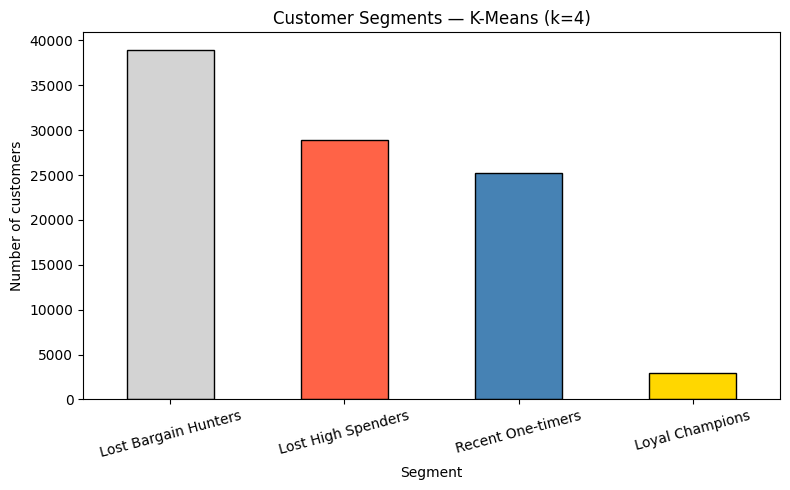

In [19]:
colors = {
    "Loyal Champions": "gold",
    "Recent One-timers": "steelblue",
    "Lost High Spenders": "tomato",
    "Lost Bargain Hunters": "lightgray"
}

rfm["segment"].value_counts().plot(
    kind="bar",
    color=[colors[s] for s in rfm["segment"].value_counts().index],
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Customer Segments — K-Means (k=4)")
plt.xlabel("Segment")
plt.ylabel("Number of customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_04_segments_bar.png", dpi=150, bbox_inches="tight")
plt.show()


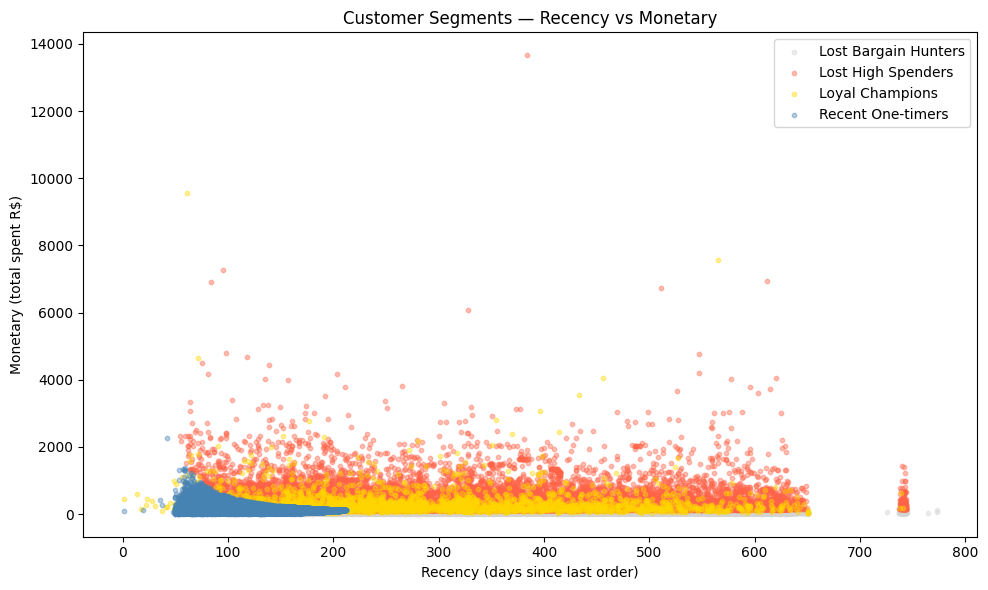

In [20]:
colors_map = {
    "Loyal Champions": "gold",
    "Recent One-timers": "steelblue",
    "Lost High Spenders": "tomato",
    "Lost Bargain Hunters": "lightgray"
}

plt.figure(figsize=(10, 6))

for segment, group in rfm.groupby("segment"):
    plt.scatter(
        group["recency"],
        group["monetary"],
        label=segment,
        color=colors_map[segment],
        alpha=0.4,
        s=10
    )

plt.title("Customer Segments — Recency vs Monetary")
plt.xlabel("Recency (days since last order)")
plt.ylabel("Monetary (total spent R$)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_05_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


The only challenge is that our RFM data is 3D (recency, frequency, monetary) and we can only plot 2D. So we'll plot Recency vs Monetary since those are the most interesting axes — they show clearly who's valuable and who's gone quiet.

Blue (Recent One-timers) → packed on the left, low recency, low spend — ordered recently but didn't spend much
Gold (Loyal Champions) → also on the left but spread higher up — recent AND high spenders, your VIPs
Red (Lost High Spenders) → spread across the whole chart, high monetary but high recency too — they spent a lot but haven't come back
Gray (Lost Bargain Hunters) → flat along the bottom everywhere — low spend, gone a long time

Hierarchical Clustering (Dendrogram)
Before we fit the model, we plot a dendrogram — it's like a family tree of clusters that helps us visually confirm how many clusters make sense.
We use a sample of 1000 rows because doing all 96k would take forever and look unreadable.

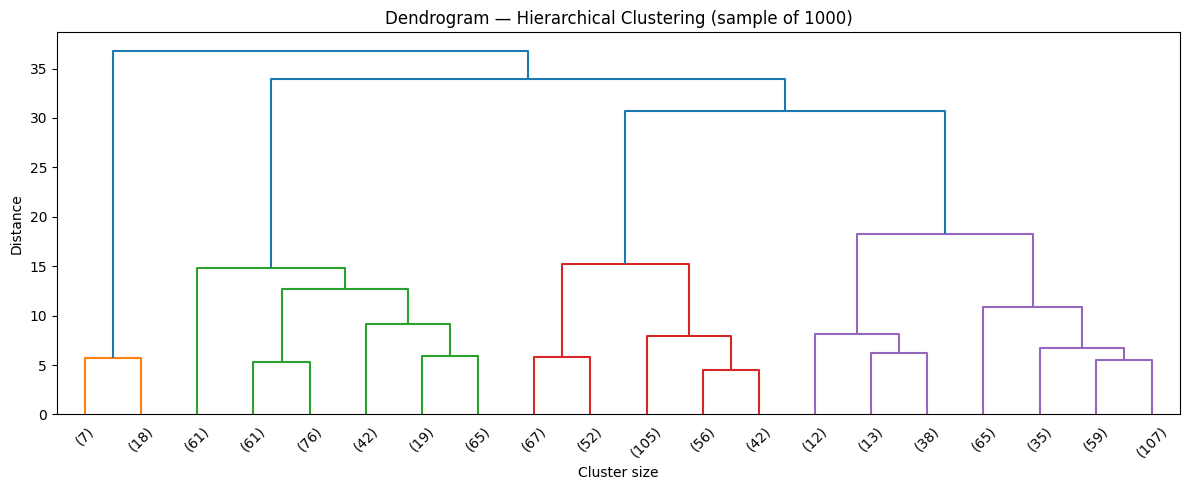

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = rfm_scaled[:1000]

linked = linkage(sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10)
plt.title("Dendrogram — Hierarchical Clustering (sample of 1000)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_06_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()


The height of each horizontal line = how different the clusters being merged are
You want to cut where the vertical lines are longest — that's where merging starts combining very different groups

the biggest jumps in distance happen at the top, and you can clearly see 4 main branches (orange, green, red, purple) before they all merge into one.
This confirms k=4 again — three independent methods (elbow, silhouette, dendrogram) all pointing to 4. That's a strong justification for your presentation!

In [22]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm["cluster_hierarchical"] = hierarchical.fit_predict(rfm_scaled)

print(rfm["cluster_hierarchical"].value_counts().sort_index())

MemoryError: Unable to allocate 34.4 GiB for an array with shape (4616884278,) and data type float64

Hierarchical clustering on 96k rows tries to compute distances between every pair of points — that's 96,000 × 96,000 = billions of numbers. No laptop can handle that 😄
The fix is simple — we run it on a sample instead. This is actually standard practice for hierarchical clustering on large datasets.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Sample 5000 rows — enough to be representative
sample_size = 5000
rfm_sample = rfm.sample(n=sample_size, random_state=42)
rfm_scaled_sample = rfm_scaled[rfm_sample.index]

hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm_sample = rfm_sample.copy()
rfm_sample["cluster_hierarchical"] = hierarchical.fit_predict(rfm_scaled_sample)

print(rfm_sample["cluster_hierarchical"].value_counts().sort_index())

otice something interesting — the pattern is very similar to K-Means!

One big cluster (~2000)
Two medium clusters (~1800, ~1000)
One tiny cluster (~143) — your VIPs again

Both methods independently found the same structure. That's a really strong validation — mention this in your presentation!

In [ ]:
from sklearn.metrics import adjusted_rand_score

# Get the kmeans labels for the same sample
kmeans_sample_labels = rfm.loc[rfm_sample.index, "cluster"]

score = adjusted_rand_score(kmeans_sample_labels, rfm_sample["cluster_hierarchical"])

print(f"Adjusted Rand Score: {score:.3f}")
print("(1.0 = perfect agreement, 0 = random)")

0.076 means the two methods don't agree much on which specific cluster each customer belongs to. But this is actually normal and here's why:

K-Means and Hierarchical clustering find clusters differently:

K-Means finds spherical clusters based on distance to a center point
Hierarchical finds tree-based clusters by merging similar neighbors bottom-up

They can find the same number of meaningful groups but label them differently and draw the boundaries differently. The low score doesn't mean one is wrong — it means they're genuinely different algorithms with different perspectives.
What matters is that both found 4 groups, both found a tiny VIP cluster. The story is consistent even if the exact assignments differ.

Both methods independently confirmed 4 segments and identified a small high-value group, despite using fundamentally different approaches

In [ ]:
rfm.to_csv("../data/processed/customer_segments.csv", index=False)

print("✅ Saved to data/processed/customer_segments.csv")
print(rfm.shape)
print(rfm.columns.tolist())